In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pretrained_vit import (PretrainedViTClassifier, load_oxford_pets, linear_probe,
                             selective_finetune, get_predictions)

tf.random.set_seed(0)
np.random.seed(0)


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train_ds, val_ds = load_oxford_pets()
model = PretrainedViTClassifier()



All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


In [3]:
hist_frozen = linear_probe(model, train_ds, val_ds, epochs=3, lr=1e-3)


  [linear probe] epoch 1 step 0  loss=3.6510
  [linear probe] epoch 1 step 20  loss=3.0196
  [linear probe] epoch 1 step 40  loss=2.5297
  [linear probe] epoch 1 step 60  loss=2.3761
  [linear probe] epoch 1 step 80  loss=2.1006
  [linear probe] epoch 1 step 100  loss=1.9598
  [linear probe] epoch 1 step 120  loss=1.4703
  [linear probe] epoch 1 step 140  loss=1.0200
  [linear probe] epoch 1 step 160  loss=1.3628
  [linear probe] epoch 1 step 180  loss=1.0201
  [linear probe] epoch 1 step 200  loss=1.0144
  [linear probe] epoch 1 step 220  loss=0.8310
[linear probe] epoch 1/3  loss=1.7848 acc=0.7356  val_loss=0.8634 val_acc=0.8531
  [linear probe] epoch 2 step 0  loss=0.8331
  [linear probe] epoch 2 step 20  loss=0.7944
  [linear probe] epoch 2 step 40  loss=0.7757
  [linear probe] epoch 2 step 60  loss=1.0058
  [linear probe] epoch 2 step 80  loss=0.5762
  [linear probe] epoch 2 step 100  loss=0.6488
  [linear probe] epoch 2 step 120  loss=0.5922
  [linear probe] epoch 2 step 140  los

In [4]:
hist_finetune = selective_finetune(model, train_ds, val_ds, epochs=3,
                                    lr_backbone=1e-5, lr_head=1e-4, unfreeze_last_k=2)



[fine-tune] Starting epoch 1/3
  [fine-tune] epoch 1 step 0 loss=0.3658
  [fine-tune] epoch 1 step 10 loss=0.3094
  [fine-tune] epoch 1 step 20 loss=0.4552
  [fine-tune] epoch 1 step 30 loss=0.1829
  [fine-tune] epoch 1 step 40 loss=0.2441
  [fine-tune] epoch 1 step 50 loss=0.3643
  [fine-tune] epoch 1 step 60 loss=0.2828
  [fine-tune] epoch 1 step 70 loss=0.3034
  [fine-tune] epoch 1 step 80 loss=0.4392
  [fine-tune] epoch 1 step 90 loss=0.4436
  [fine-tune] epoch 1 step 100 loss=0.1753
  [fine-tune] epoch 1 step 110 loss=0.3342
  [fine-tune] epoch 1 step 120 loss=0.7024
  [fine-tune] epoch 1 step 130 loss=0.2758
  [fine-tune] epoch 1 step 140 loss=0.5717
  [fine-tune] epoch 1 step 150 loss=0.2693
  [fine-tune] epoch 1 step 160 loss=0.2848
  [fine-tune] epoch 1 step 170 loss=0.2083
  [fine-tune] epoch 1 step 180 loss=0.3675
  [fine-tune] epoch 1 step 190 loss=0.6064
  [fine-tune] epoch 1 step 200 loss=0.2140
  [fine-tune] epoch 1 step 210 loss=0.2342
  [fine-tune] epoch 1 step 220 lo

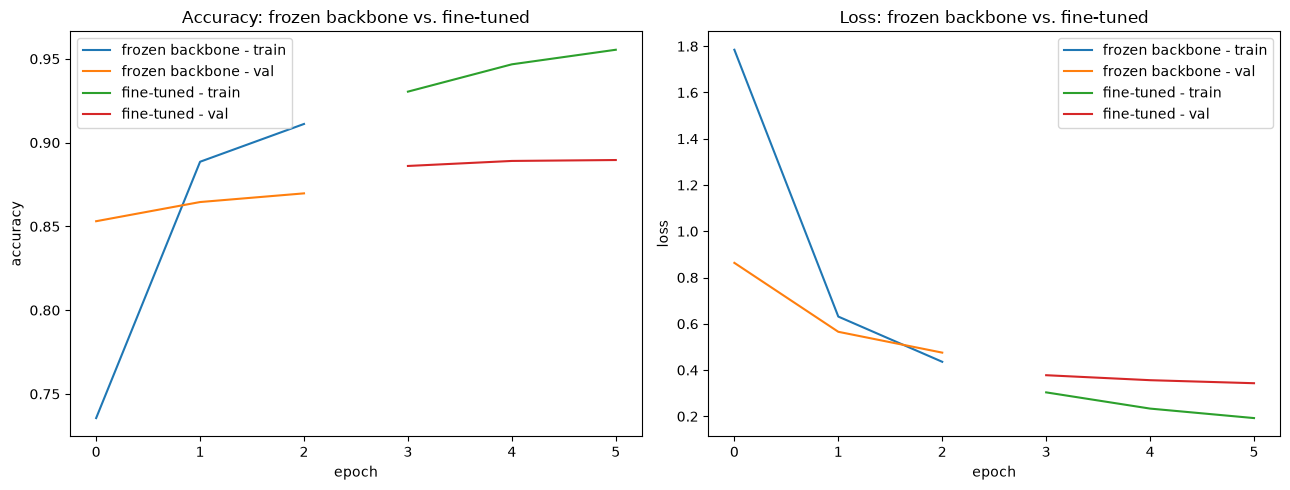

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist_frozen["accuracy"], label="frozen backbone - train")
axes[0].plot(hist_frozen["val_accuracy"], label="frozen backbone - val")
offset = len(hist_frozen["accuracy"])
ft_x = range(offset, offset + len(hist_finetune["accuracy"]))
axes[0].plot(ft_x, hist_finetune["accuracy"], label="fine-tuned - train")
axes[0].plot(ft_x, hist_finetune["val_accuracy"], label="fine-tuned - val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy: frozen backbone vs. fine-tuned")
axes[0].legend()

axes[1].plot(hist_frozen["loss"], label="frozen backbone - train")
axes[1].plot(hist_frozen["val_loss"], label="frozen backbone - val")
axes[1].plot(ft_x, hist_finetune["loss"], label="fine-tuned - train")
axes[1].plot(ft_x, hist_finetune["val_loss"], label="fine-tuned - val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss")
axes[1].set_title("Loss: frozen backbone vs. fine-tuned")
axes[1].legend()
plt.tight_layout()
plt.show()


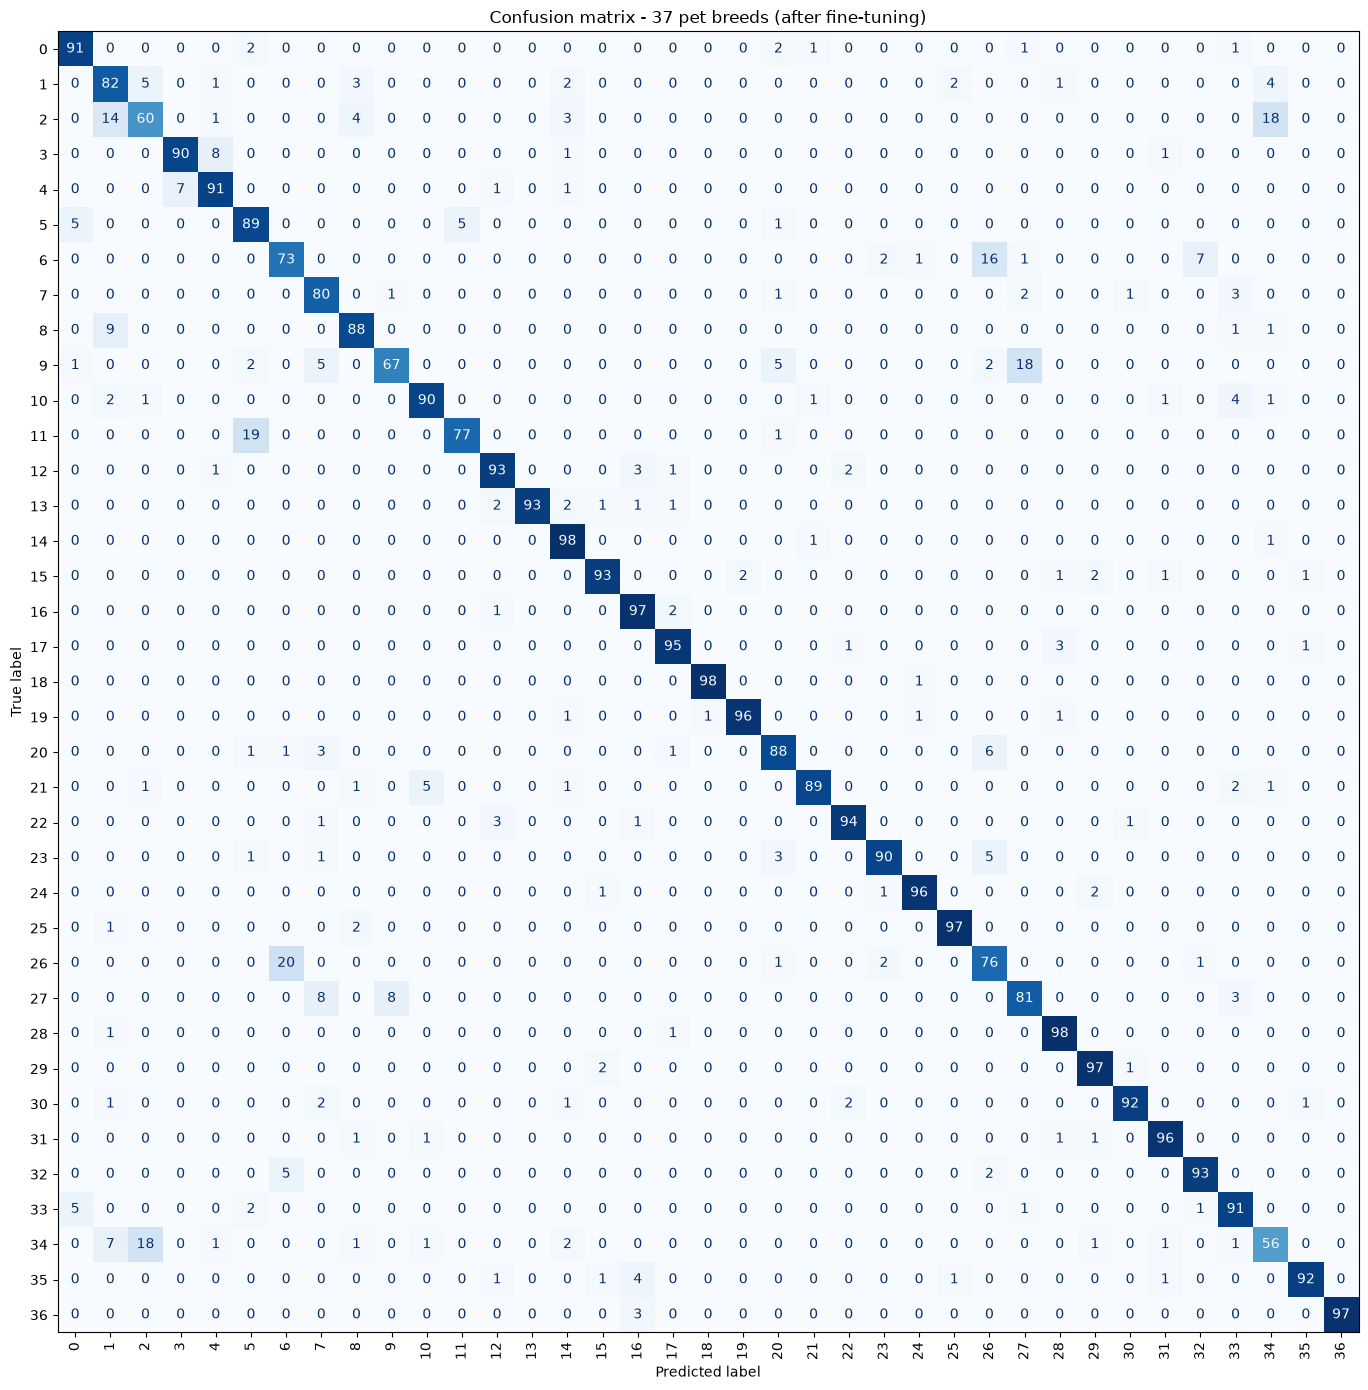

final validation accuracy: 0.8896


In [6]:
y_true, y_pred = get_predictions(model, val_ds)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)
plt.title("Confusion matrix - 37 pet breeds (after fine-tuning)")
plt.tight_layout()
plt.show()

accuracy = np.trace(cm) / np.sum(cm)
print(f"final validation accuracy: {accuracy:.4f}")
